In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample

### Plot Styles

In [2]:
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120})

### Load Data Path

In [ ]:
EXTRACTED_DIR = Path("../Extracted_data")          
LOG_CSV       = Path("../extraction_log.csv")        
CLEAN_CSV     = Path("../dataset_clean.csv")        # output: cleaned, original dist -> fairness/SHAP
OUTPUT_CSV    = Path("../dataset_balanced.csv")     # output: resampled -> DistilBERT training

### Fix UTF-8

In [4]:
import ftfy

# Apply ftfy to all .txt files before cleaning
fixed_count = 0
for txt_file in sorted(EXTRACTED_DIR.glob("**/*.txt")):
    raw   = txt_file.read_text(encoding="utf-8", errors="replace")
    fixed = ftfy.fix_text(raw)
    if fixed != raw:
        txt_file.write_text(fixed, encoding="utf-8")
        fixed_count += 1

print(f"ftfy applied (v)")
print(f"Files with encoding artifacts fixed: {fixed_count}")

# Quick sanity check — show before/after on a sample
sample = 'Responsbilityâ€¢ Maintain Â· clean Â§ safe'
print(f"\nBefore: {sample}")
print(f"After : {ftfy.fix_text(sample)}")


ftfy applied (v)
Files with encoding artifacts fixed: 1015

Before: Responsbilityâ€¢ Maintain Â· clean Â§ safe
After : Responsbility• Maintain · clean § safe


### Text Cleaning & PII Removal

In [7]:
# PII patterns 
_PHONE   = re.compile(r"(?:\+?1[\s\-.])?" r"(?:\(?\d{3}\)?[\s\-.])" r"\d{3}[\s\-.]?\d{4}")
_EMAIL   = re.compile(r"[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+")
_URL     = re.compile(
    r"(?:https?://|www\.)"
    r"(?:linkedin\.com|github\.com|twitter\.com|facebook\.com|instagram\.com)"
    r"[^\s]*",
    re.IGNORECASE
)
_ADDRESS = re.compile(
    r"\d{1,5}\s+(?:[A-Z][a-z]+\s+){1,4}"
    r"(?:St|Ave|Rd|Blvd|Dr|Ln|Way|Court|Ct|Place|Pl|Suite|Ste)\.?",
    re.IGNORECASE
)
_NAME_TOP = re.compile(r"^(?:[A-Z][a-z]+\s+){1,3}[A-Z][a-z]+")
_PHOTO    = re.compile(r"(?:profile\s*photo|photo\.(?:jpg|jpeg|png|gif))", re.IGNORECASE)
_PAGE_TAG = re.compile(r"---\s*Page\s*\d+(?:\s*\(OCR\))?\s*---")

def clean_resume(text: str) -> str:
    # 1. Remove page markers
    text = _PAGE_TAG.sub(" ", text)

    # 2. Strip PII
    text = _NAME_TOP.sub("[NAME]", text, count=1)
    text = _PHONE.sub("[PHONE]", text)
    text = _EMAIL.sub("[EMAIL]", text)
    text = _URL.sub("[SOCIAL]", text)
    text = _ADDRESS.sub("[ADDRESS]", text)
    text = _PHOTO.sub("[PHOTO]", text)

    # 3. Collapse whitespace (tabs, newlines -> single space)
    text = re.sub(r"[\t\r\n]+", " ", text)
    text = re.sub(r" {2,}", " ", text)

    # 4. Lowercase
    return text.lower().strip()

# Quick sanity check
print("=== Sanity Check ===")
sample_path = next(EXTRACTED_DIR.glob("**/*.txt"))
raw = sample_path.read_text(encoding="utf-8")
print("Sample output (300 chars):")
print(clean_resume(raw)[:300])


=== Sanity Check ===
Sample output (300 chars):
accountant summary financial accountant specializing in financial planning, reporting and analysis within the department of defense. highlights account reconciliations results-oriented accounting operations professional financial reporting analysis of financial systems critical thinking erp (enterpr


In [8]:
cleaning_report = []

for txt_file in sorted(EXTRACTED_DIR.glob("**/*.txt")):
    raw     = txt_file.read_text(encoding="utf-8")
    cleaned = clean_resume(raw)

    wc_before = len(raw.split())
    wc_after  = len(cleaned.split())

    txt_file.write_text(cleaned, encoding="utf-8")

    pii_tags = ["[phone]", "[email]", "[social]", "[address]", "[name]"]
    cleaning_report.append({
        "occupation": txt_file.parent.name,
        "filename":   txt_file.name,
        "wc_before":  wc_before,
        "wc_after":   wc_after,
        "pii_found":  any(tag in cleaned for tag in pii_tags),
    })

clean_report_df = pd.DataFrame(cleaning_report)
print(f"Files cleaned  : {len(clean_report_df)}")
print(f"PII detected   : {clean_report_df['pii_found'].sum()} file(s)")
print(f"Avg words before : {clean_report_df['wc_before'].mean():.0f}")
print(f"Avg words after  : {clean_report_df['wc_after'].mean():.0f}")


Files cleaned  : 2482
PII detected   : 854 file(s)
Avg words before : 818
Avg words after  : 808


In [ ]:
# Reload df from cleaned .txt files
records = []
for occ_dir in sorted(EXTRACTED_DIR.iterdir()):
    if not occ_dir.is_dir():
        continue
    for txt_file in sorted(occ_dir.glob("*.txt")):
        text = txt_file.read_text(encoding="utf-8")
        records.append({
            "occupation": occ_dir.name,
            "filename":   txt_file.name,
            "text":       text,
            "char_count": len(text),
            "word_count": len(text.split()),
        })

df = pd.DataFrame(records)
df["tokens"]     = df["text"].apply(lambda t: re.findall(r"\b[a-z]{3,}\b", t))
df["vocab_size"] = df["tokens"].apply(lambda t: len(set(t)))

print(f"df reloaded: {len(df)} resumes")
print(df[["occupation", "filename", "word_count", "vocab_size"]].head(8))


df reloaded: 2482 resumes
   occupation      filename  word_count  vocab_size
0  ACCOUNTANT  10554236.txt        3469         916
1  ACCOUNTANT  10674770.txt        1042         412
2  ACCOUNTANT  11163645.txt         628         260
3  ACCOUNTANT  11759079.txt         849         367
4  ACCOUNTANT  12065211.txt         780         368
5  ACCOUNTANT  12202337.txt         741         314
6  ACCOUNTANT  12338274.txt         810         271
7  ACCOUNTANT  12442909.txt         653         312


In [12]:
# Save cleaned dataset (original distribution, no resampling)
# Used for fairness metrics & SHAP - reflects real-world class distribution
cols = ["occupation", "filename", "text", "word_count", "char_count", "vocab_size"]
df[cols].to_csv(CLEAN_CSV, index=False)

print(f"Saved : {CLEAN_CSV}")
print(f"Shape : {df.shape}")
print(f"\nClass distribution (original):")
print(df["occupation"].value_counts().to_string())
print("\n-> Used for fairness metrics & SHAP - reflects real-world class distribution")



Saved : ..\dataset_clean.csv
Shape : (2482, 7)

Class distribution (original):
occupation
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      119
ACCOUNTANT                118
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
FINANCE                   118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
CONSULTANT                115
HEALTHCARE                115
CONSTRUCTION              112
HR                        110
PUBLIC-RELATIONS          110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22

-> Used for fairness metrics & SHAP - reflects real-world class distribution


## 9. Class Imbalance Analysis & Handling

Strategy based on imbalance ratio:
- **< 3×** → minor, use `class_weight='balanced'` in model only
- **3–10×** → moderate, oversample minority + class weights
- **> 10×** → severe, oversample + undersample + class weights

Majority class : INFORMATION-TECHNOLOGY (120)
Minority class : BPO (22)
Imbalance ratio: 5.45x
Verdict: Moderate imbalance — oversample minority + class weights


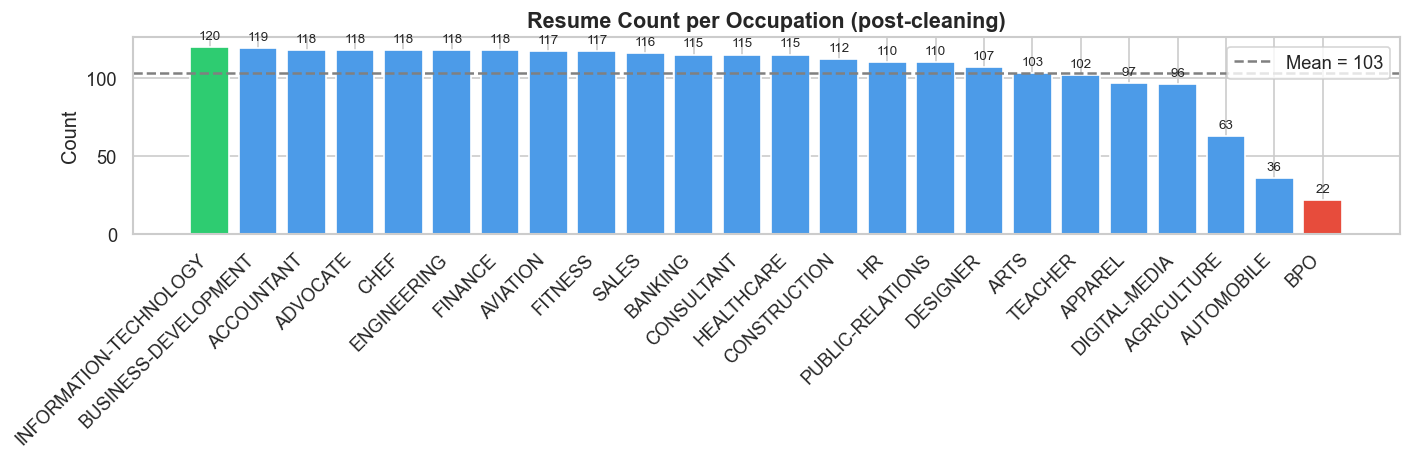

In [13]:
occ_counts = df["occupation"].value_counts().reset_index()
occ_counts.columns = ["occupation", "count"]

majority = occ_counts["count"].max()
minority = occ_counts["count"].min()
ratio    = majority / minority

print(f"Majority class : {occ_counts.iloc[0]['occupation']} ({majority})")
print(f"Minority class : {occ_counts.iloc[-1]['occupation']} ({minority})")
print(f"Imbalance ratio: {ratio:.2f}x")

if ratio < 3:
    verdict = "Minor imbalance — class_weight='balanced' sufficient"
elif ratio < 10:
    verdict = "Moderate imbalance — oversample minority + class weights"
else:
    verdict = "Severe imbalance — oversample + undersample + class weights"
print(f"Verdict: {verdict}")

fig, ax = plt.subplots(figsize=(12, 4))
colors = [
    "#e74c3c" if c == minority else
    "#2ecc71" if c == majority else
    "#4C9BE8"
    for c in occ_counts["count"]
]
bars = ax.bar(occ_counts["occupation"], occ_counts["count"], color=colors)
ax.bar_label(bars, padding=3, fontsize=8)
ax.axhline(occ_counts["count"].mean(), color="gray", linestyle="--",
           label=f"Mean = {occ_counts['count'].mean():.0f}")
ax.set_title("Resume Count per Occupation (post-cleaning)", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
TARGET_N = int(occ_counts["count"].median())
print(f"Target count per class (median): {TARGET_N}\n")

balanced_dfs = []

for occ in df["occupation"].unique():
    occ_df = df[df["occupation"] == occ]
    n      = len(occ_df)

    if n < TARGET_N:
        resampled = resample(occ_df, replace=True,
                             n_samples=TARGET_N, random_state=42)
        tag = f"oversampled  {n:>3} → {TARGET_N}"
    elif n > TARGET_N:
        resampled = resample(occ_df, replace=False,
                             n_samples=TARGET_N, random_state=42)
        tag = f"undersampled {n:>3} → {TARGET_N}"
    else:
        resampled = occ_df
        tag = f"unchanged    {n:>3}"

    balanced_dfs.append(resampled)
    print(f"  {occ:<25} {tag}")

df_balanced = pd.concat(balanced_dfs).reset_index(drop=True)
print(f"\nBalanced df: {df_balanced.shape[0]} rows x {df_balanced.shape[1]} cols")


Target count per class (median): 115

  ACCOUNTANT                undersampled 118 → 115
  ADVOCATE                  undersampled 118 → 115
  AGRICULTURE               oversampled   63 → 115
  APPAREL                   oversampled   97 → 115
  ARTS                      oversampled  103 → 115
  AUTOMOBILE                oversampled   36 → 115
  AVIATION                  undersampled 117 → 115
  BANKING                   unchanged    115
  BPO                       oversampled   22 → 115
  BUSINESS-DEVELOPMENT      undersampled 119 → 115
  CHEF                      undersampled 118 → 115
  CONSTRUCTION              oversampled  112 → 115
  CONSULTANT                unchanged    115
  DESIGNER                  oversampled  107 → 115
  DIGITAL-MEDIA             oversampled   96 → 115
  ENGINEERING               undersampled 118 → 115
  FINANCE                   undersampled 118 → 115
  FITNESS                   undersampled 117 → 115
  HEALTHCARE                unchanged    115
  HR       